In [1]:
%matplotlib inline
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib
import scipy.interpolate as interpolate
import scipy.signal as signal
from matplotlib.patches import Rectangle
import scipy.stats as stats
import scipy.constants as const
import scipy.optimize as optimize
import scipy.interpolate as interpolate
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm  # For register_cmap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, FixedLocator
from sklearn.linear_model import LinearRegression


**Settings** 

In [2]:
custom_blue = (0.0, 0.5, 0.9, 1.0)  # RGB for blue (#0099FF)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colors = original_cmap(np.linspace(0, 1, n_colors))

colors[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap = ListedColormap(colors)

dark_red = np.array([0.7, 0.05, 0.15, 1.0], dtype=np.float64)

custom_green = (13/256, 179/256, 45/256, 1.0)
custom_blue = (34/255, 125/255, 251/255, 1)  # RGB for blue #227DFB
custom_red = (209/255, 37/255, 55/255, 1)  # RGB for red #D1254E

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsB = original_cmap(np.linspace(0, 1, n_colors))

colorsB[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap_blue = ListedColormap(colorsB)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsR = original_cmap(np.linspace(0, 1, n_colors))

colorsR[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_red, 128)  # Fade from gray to blue
custom_cmap_red = ListedColormap(colorsR)

matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    # 'text.usetex': True
})

# Device D

## Weak Electron

Measurement (i)

Calculated SOC (Energy Splitting): 0.10278 meV
Standard Deviation: 0.01193 meV


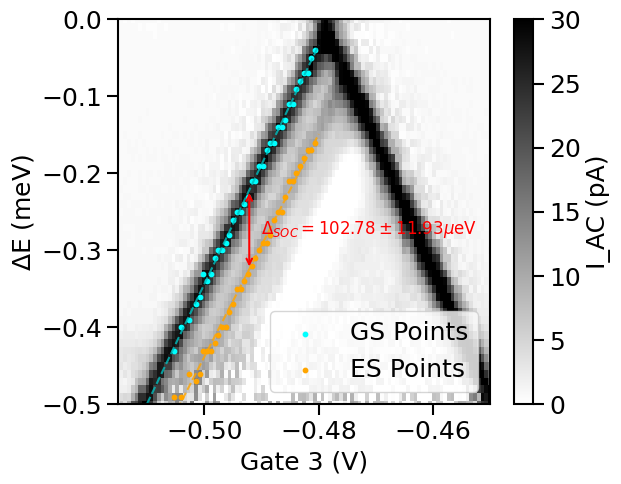

In [4]:
name='C0062 4VBGm 1e Diamond MG'
filename='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,5,:]*1e-8
# Convert raw data to physical units
y_all = V_PG[:, 0:101]  # Gate 3 (V)
x_all = V_SD[:, 0:101]  # B⊥ (mT)
z_all = I_ACx[:, 0:101] * 1e12  # pA

# Choose a y value above which data should be shifted
y_jump_value = 0  # V (Gate 3)
x_shift = 0  # mT shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (-0.515, -0.450)  # for Gate 3 (V)
y_range = (-0.5, 0)  # for B⊥ (mT)

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# --- CONFIGURATION ---
roi_gate_min = -0.510
roi_gate_max = -0.480
min_peak_height = 3     # Adjust based on noise floor
min_peak_distance = 5   # Min separation between peaks
prominence_val = 2      # How much a peak stands out

# Locate ROI indices
gate_values = x_centers 
roi_indices = np.where((gate_values >= roi_gate_min) & (gate_values <= roi_gate_max))[0]

# Lists to store PAIRED coordinates (only when both are found)
pairs_gate = []
pairs_gs_energy = []
pairs_es_energy = []

# --- PEAK DETECTION ---
for col_idx in roi_indices:
    trace = z_all[:, col_idx]
    
    # Find peaks
    peaks, properties = find_peaks(trace, height=min_peak_height, distance=min_peak_distance, prominence=prominence_val)
    
    if len(peaks) > 0:
        # 1. Identify GS (Brightest Peak)
        max_height_idx = np.argmax(properties['peak_heights'])
        gs_idx = peaks[max_height_idx]
        gs_E = y_centers[gs_idx]
        
        # 2. Identify ES (Candidate below GS)
        # Look for peaks with lower energy (more negative y-value)
        candidate_indices = [p for p in peaks if y_centers[p] < (gs_E - 0.005)]
        
        if len(candidate_indices) > 0:
            # Pick the candidate closest to GS (highest energy among candidates)
            es_idx = candidate_indices[np.argmax([y_centers[p] for p in candidate_indices])]
            es_E = y_centers[es_idx]
            
            # Save the pair
            pairs_gate.append(gate_values[col_idx])
            pairs_gs_energy.append(gs_E)
            pairs_es_energy.append(es_E)

# Convert to arrays for vector math
gate_arr = np.array(pairs_gate)
gs_arr = np.array(pairs_gs_energy)
es_arr = np.array(pairs_es_energy)

# --- CALCULATE SOC (ENERGY SPLITTING) ---
if len(gate_arr) > 3:
    # Calculate vertical distance for every single point pair
    energy_diffs = np.abs(gs_arr - es_arr)
    
    # The SOC is the average splitting
    soc_energy = np.mean(energy_diffs)
    soc_std = np.std(energy_diffs)
    
    print(f"Calculated SOC (Energy Splitting): {soc_energy:.5f} meV")
    print(f"Standard Deviation: {soc_std:.5f} meV")
    
    # Optional: Fit lines just for plotting (to make it look nice)
    model_gs = LinearRegression().fit(gate_arr.reshape(-1, 1), gs_arr)
    model_es = LinearRegression().fit(gate_arr.reshape(-1, 1), es_arr)
    
    # Create smooth lines for plotting
    x_fit = np.linspace(roi_gate_min, roi_gate_max, 100)
    y_fit_gs = model_gs.predict(x_fit.reshape(-1, 1))
    y_fit_es = model_es.predict(x_fit.reshape(-1, 1))

else:
    print("Not enough paired points found.")
    soc_energy = 0

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
pcm = ax.pcolormesh(x_edges, y_edges, z_all, cmap='binary', vmin=0, vmax=30)
cbar = plt.colorbar(pcm, label='I_AC (pA)')

# Plot the raw detected pairs
ax.scatter(gate_arr, gs_arr, c='cyan', s=10, label='GS Points')
ax.scatter(gate_arr, es_arr, c='orange', s=10, label='ES Points')

# Plot the fitted lines
if len(gate_arr) > 3:
    ax.plot(x_fit, y_fit_gs, 'c--', lw=1.5, alpha=0.8)
    ax.plot(x_fit, y_fit_es, color='orange', linestyle='--', lw=1.5, alpha=0.8)
    
    # Visualizing the SOC splitting
    # Draw a vertical arrow at the center of the range
    mid_x = np.mean(gate_arr)
    mid_y_gs = model_gs.predict([[mid_x]])[0]
    mid_y_es = model_es.predict([[mid_x]])[0]
    
    ax.annotate(
        '', xy=(mid_x, mid_y_gs), xytext=(mid_x, mid_y_es),
        arrowprops=dict(arrowstyle='<->', color='red', lw=1.5)
    )
    ax.text(mid_x + 0.002, (mid_y_gs + mid_y_es)/2, 
            f'$\\Delta_{{SOC}} = {soc_energy*1000:.2f} \\pm {soc_std*1000:.2f} \\mu$eV', 
            color='red', fontsize=12, va='center')

ax.set_ylim(-0.5, 0)
ax.set_xlim(-0.515, -0.45)
ax.set_xlabel('Gate 3 (V)')
ax.set_ylabel(r'$\Delta$E (meV)')
ax.legend()
plt.show()
